In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.shape

(891, 12)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [7]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
train.drop_duplicates()
test.drop_duplicates()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [9]:
# надо смотреть выбросы и тип данных (категориальные или нет), чтобы понять, чем заполнить пропуски. 
# если еще и выброс в числовом, то лучше использовать медиану. выброса нет - среднее. для категориальных - мода. 

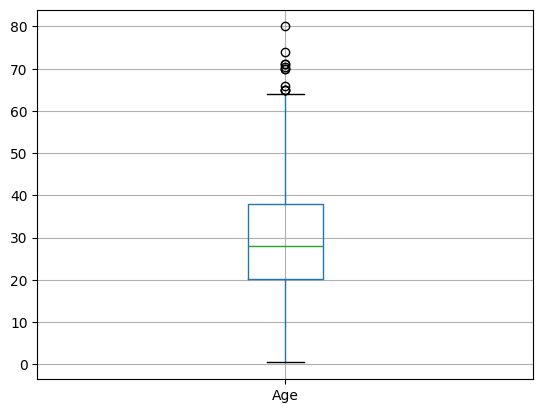

In [10]:
train.boxplot(column=['Age']) 
plt.show()

In [11]:
# выбросы + числовое -> медиана
median_age = train['Age'].mean()
train['Age'].fillna(median_age, inplace=True)
train.isna().sum()
test['Age'].fillna(median_age, inplace=True)
train.isna().sum()

/var/folders/7c/31qz061x195d5qkrqjg973v00000gn/T/ipykernel_82920/2071681770.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(median_age, inplace=True)
/var/folders/7c/31qz061x195d5qkrqjg973v00000gn/T/ipykernel_82920/2071681770.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
# больше половины данных в Cabin отсутствует, так что я не вижу смысла их заменять модой

In [13]:
# проверим значения в embarked 
train.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [14]:
# в embarked вместо 2 пропусков вставим моду
mode_embarked = train['Embarked'].mode()[0]
train['Embarked'].fillna(mode_embarked, inplace=True)
train.isna().sum()
test['Embarked'].fillna(mode_embarked, inplace=True)
test.isna().sum()

/var/folders/7c/31qz061x195d5qkrqjg973v00000gn/T/ipykernel_82920/758928907.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Embarked'].fillna(mode_embarked, inplace=True)
/var/folders/7c/31qz061x195d5qkrqjg973v00000gn/T/ipykernel_82920/758928907.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [15]:
# теперь можно поиграться с графиками

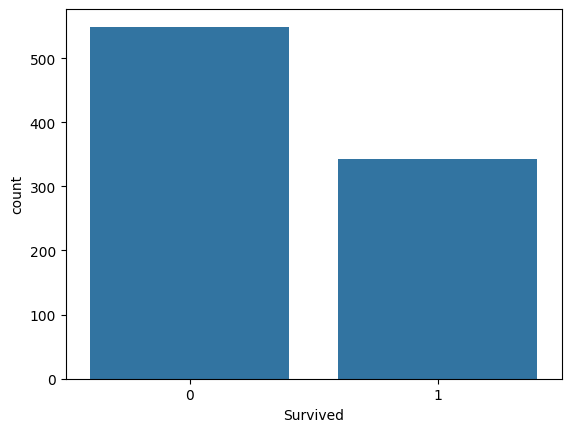

In [16]:
sns.countplot(x='Survived', data=train)
plt.show()
# как видим, большинство не выжило (кто бы мог подумать)

In [17]:
# пытаемся найти зависимость между шансом выжить и еще чем-то
train.groupby('Sex').Survived.value_counts()
#женщин выжило больше, можно из этого еще и график сделать

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

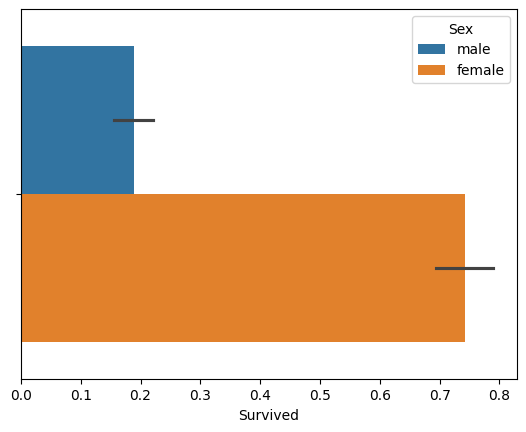

In [18]:
sns.barplot(x='Survived', hue='Sex', data=train)
plt.show()

In [19]:
# зависит ли шанс выжить от класса билета
train.groupby('Pclass').Survived.value_counts()
# судя по всему, зависимость была

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

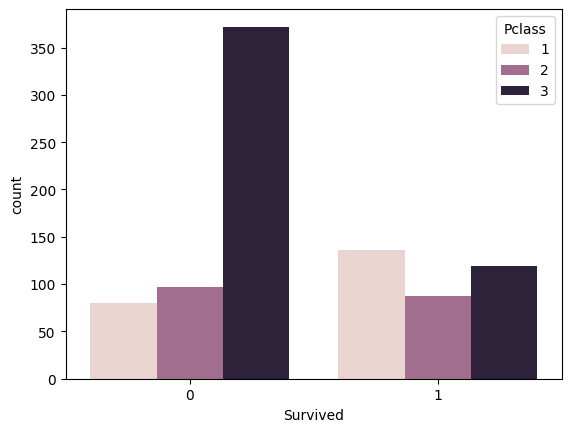

In [20]:
sns.countplot(x='Survived', hue='Pclass', data=train) 
plt.show()

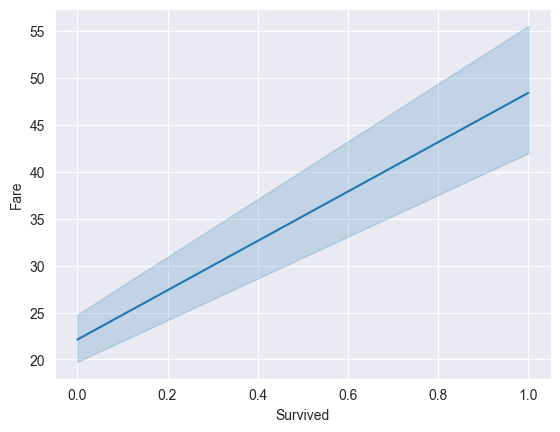

In [21]:
# получается, что чем выше класс, тем больше выживших. из таблицы видно, что чем больше плата за проезд, 
# тем выше класс, и ,тогда, больше шансов выжить. проверяем
sns.set_style('darkgrid')
sns.lineplot(data = train, x = "Survived", y = "Fare")
plt.show()

In [22]:
#еще мы не затронули parch и sibsp. если мы сложим эти значения +1, то получим кол-ва членов семьи, и посмотрим, влияет ли это на шанс выжить
family = train[['SibSp', 'Parch']].sum(axis=1) + 1
train.insert(8, 'People in family', family)
test.insert(8, 'People in family', family)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,People in family,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,2,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,2,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,1,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,2,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,1,373450,8.0500,NaN,S


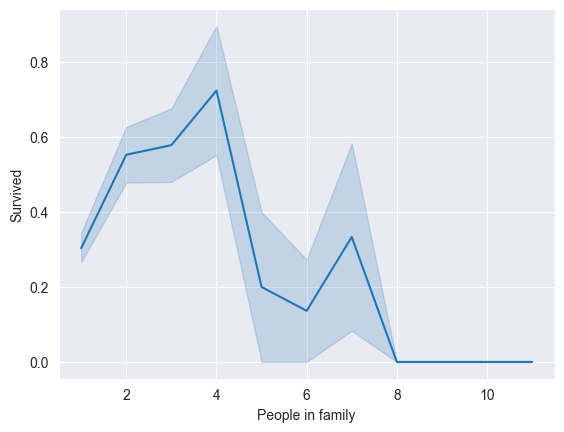

In [23]:
# визуализируем
sns.set_style('darkgrid')
sns.lineplot(data = train, x = "People in family", y = "Survived")
plt.show()

In [24]:
# перед корелляцией лучше преобразовать качественные признаки в числа
train_encoded = pd.get_dummies(train, columns=['Sex'], prefix='Sex')
train_encoded.head()
test_encoded = pd.get_dummies(test, columns=['Sex'], prefix='Sex')

In [25]:
train_encoded_2 = pd.get_dummies(train_encoded, columns=['Embarked'], prefix='Embarked')
train_encoded_2.head()
test_encoded_2 = pd.get_dummies(test_encoded, columns=['Embarked'], prefix='Embarked')
train_encoded_2.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,People in family,Ticket,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,2,A/5 21171,7.2500,NaN,False,True,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,2,PC 17599,71.2833,C85,True,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,1,STON/O2. 3101282,7.9250,NaN,True,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,2,113803,53.1000,C123,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,1,373450,8.0500,NaN,False,True,False,False,True


In [26]:
train = train_encoded_2.drop(['Name', 'SibSp', 'Parch','Cabin', 'Ticket'], axis=1)
train.head()
test = test_encoded_2.drop(['Name', 'SibSp', 'Parch','Cabin', 'Ticket'], axis=1)
train.head()

,PassengerId,Survived,Pclass,Age,People in family,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,2,7.2500,False,True,False,False,True
1,2,1,1,38.0,2,71.2833,True,False,True,False,False
2,3,1,3,26.0,1,7.9250,True,False,False,False,True
3,4,1,1,35.0,2,53.1000,True,False,False,False,True
4,5,0,3,35.0,1,8.0500,False,True,False,False,True


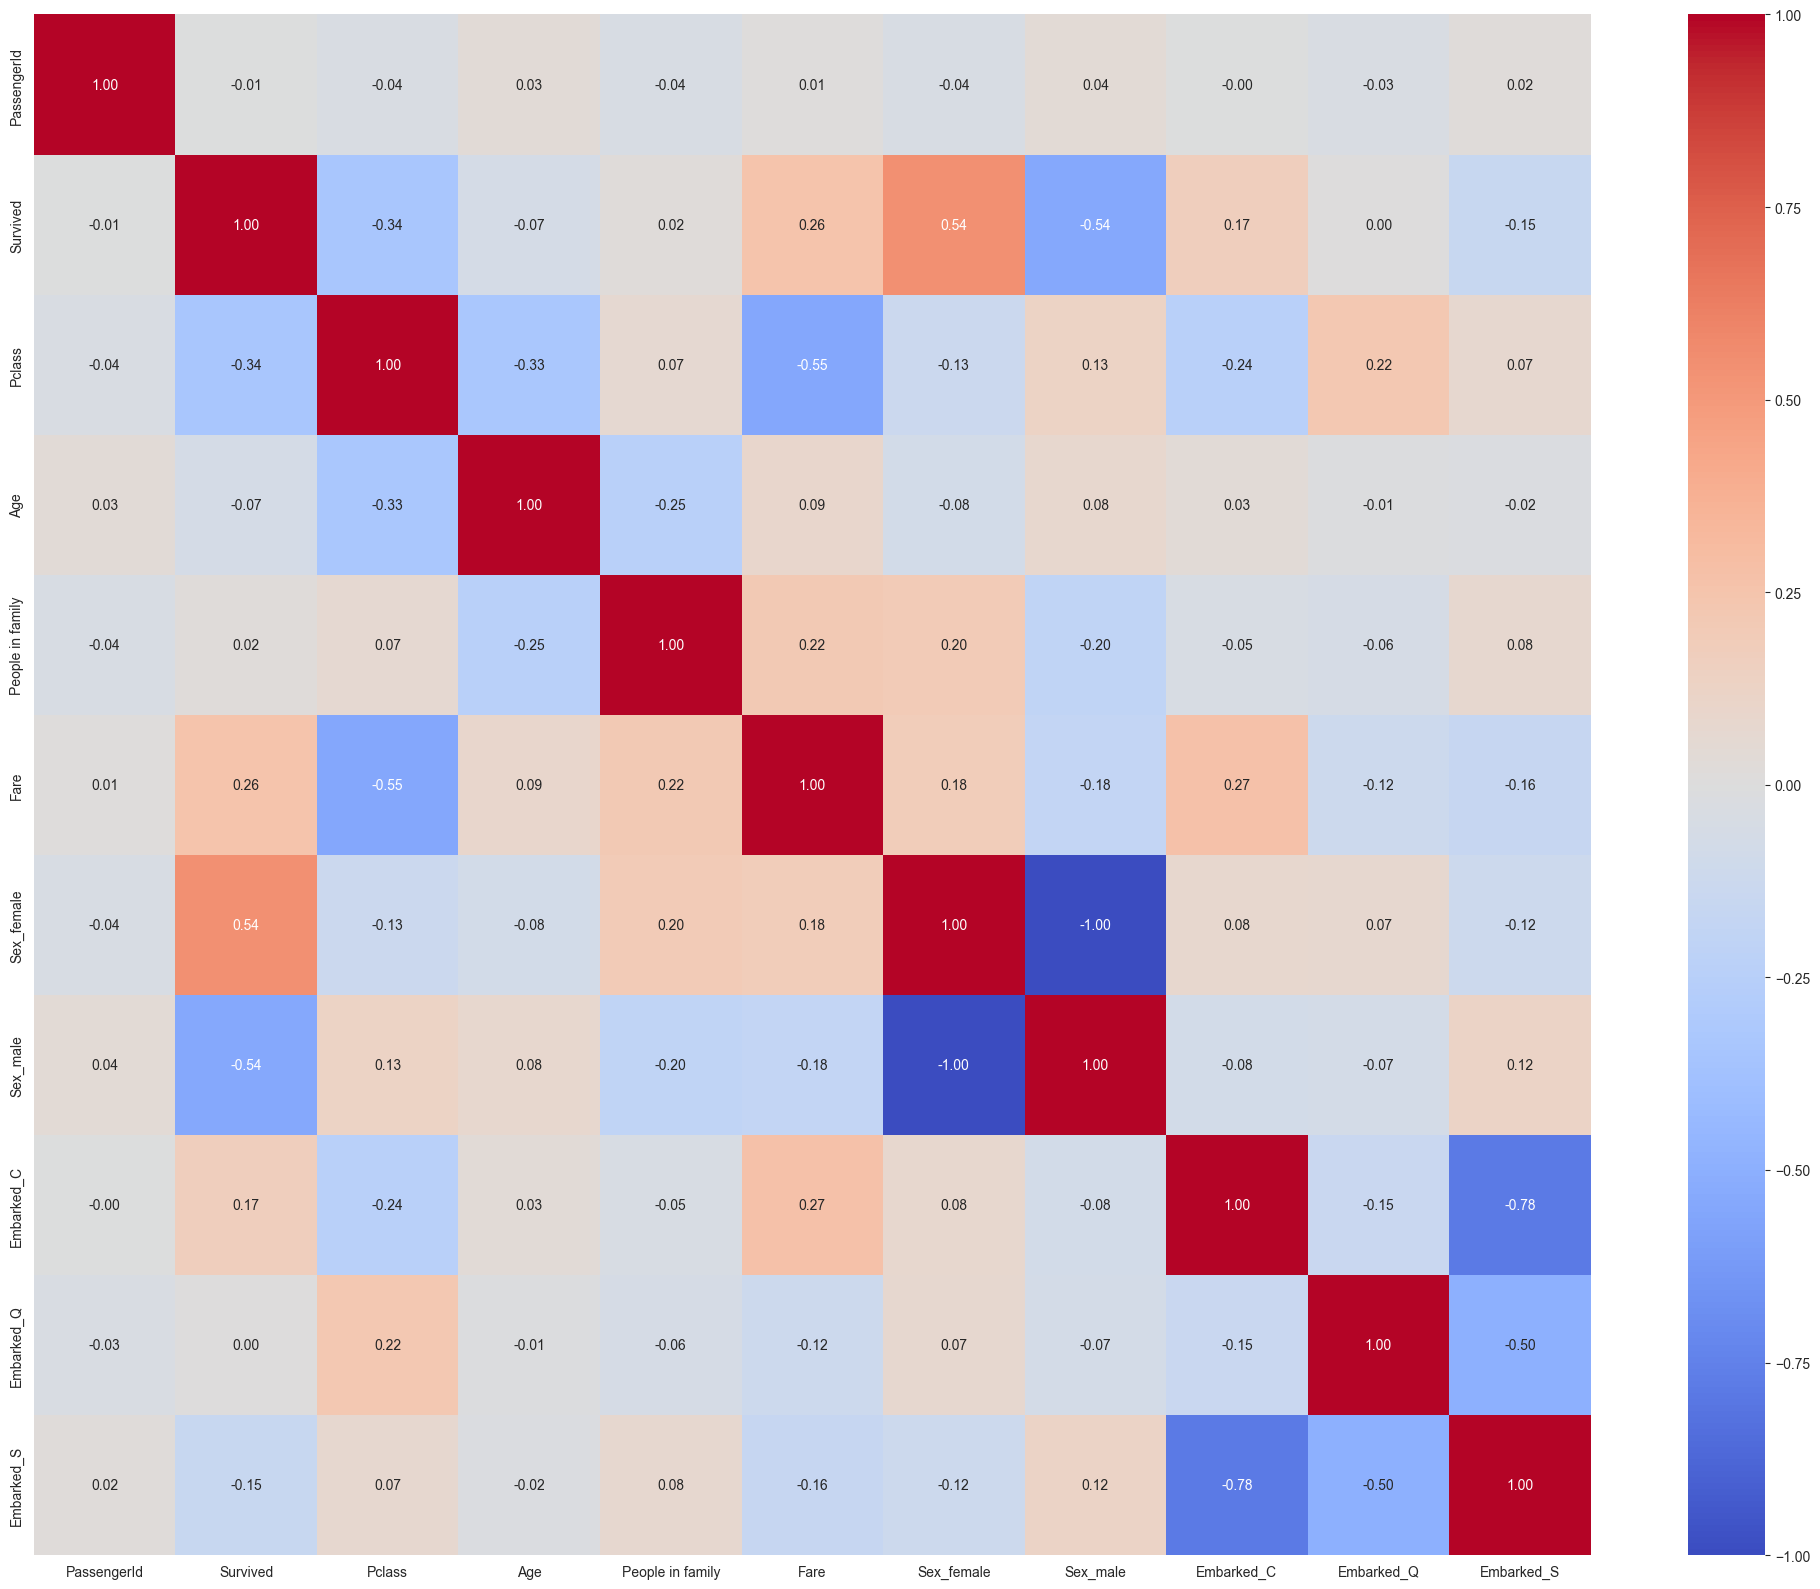

In [27]:
correlation = train.corr(numeric_only=True)
plt.figure(figsize=(20, 16))  
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.show()

In [28]:
# начнем самую неприятную часть
X_train = train.drop('Survived', axis=1)
y_train = train['Survived']

X_test = test.copy()
# идем по схеме тренировочное -> тестовое -> замер точности

In [29]:
mode_embarked = X_test['Fare'].mode()[0]
X_test['Fare'].fillna(mode_embarked, inplace=True)
X_test.isna().sum()

/var/folders/7c/31qz061x195d5qkrqjg973v00000gn/T/ipykernel_82920/2498301037.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['Fare'].fillna(mode_embarked, inplace=True)


PassengerId         0
Pclass              0
Age                 0
People in family    0
Fare                0
Sex_female          0
Sex_male            0
Embarked_C          0
Embarked_Q          0
Embarked_S          0
dtype: int64

In [30]:
lg = LogisticRegression(max_iter=1000)
lg.fit(X_train, y_train)
y_pred_lg = lg.predict(X_test)
acc_lg = round(lg.score(X_train, y_train) * 100, 2)
acc_lg

80.25

In [31]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = round(knn.score(X_train, y_train) * 100, 2)
acc_knn

79.91

In [32]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = round(dt.score(X_train, y_train) * 100, 2)
acc_dt

100.0

In [33]:
test.head()

,PassengerId,Pclass,Age,People in family,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,892,3,34.5,2,7.8292,False,True,False,True,False
1,893,3,47.0,2,7.0000,True,False,False,False,True
2,894,2,62.0,1,9.6875,False,True,False,True,False
3,895,3,27.0,2,8.6625,False,True,False,False,True
4,896,3,22.0,1,12.2875,True,False,False,False,True


In [36]:
result = pd.DataFrame({
        "PassengerId": test["PassengerId"],
        "Survived": y_pred_lg
    })

result.to_csv('result_3.csv', index=False)